<!--
  Licensed to the Apache Software Foundation (ASF) under one or more
  contributor license agreements.  See the NOTICE file distributed with
  this work for additional information regarding copyright ownership.
  The ASF licenses this file to You under the Apache License, Version 2.0
  (the "License"); you may not use this file except in compliance with
  the License.  You may obtain a copy of the License at

       http://www.apache.org/licenses/LICENSE-2.0

  Unless required by applicable law or agreed to in writing, software
  distributed under the License is distributed on an "AS IS" BASIS,
  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
  See the License for the specific language governing permissions and
  limitations under the License.
-->

# Hudi VECTOR + BLOB — Main Demo

Single notebook for the canonical Hudi 1.2.0 unstructured-data story: Parquet base files with **inline BLOBs** and **`hudi_vector_search` + `read_blob()`** composed in one SQL query — top-K nearest neighbors, with bytes materialized only for the matching rows.

To run on Lance base files instead, change `'hoodie.table.base.file.format' = 'parquet'` to `'lance'` in §4's DDL — no other code changes needed.

Deeper-dives: [`01_blob_reader.ipynb`](01_blob_reader.ipynb) (OUT_OF_LINE + DESCRIPTOR), [`02_sql_vector_search.ipynb`](02_sql_vector_search.ipynb) (SQL DDL), [`03_dataframe_vector_search.ipynb`](03_dataframe_vector_search.ipynb) (DataFrame API).

## 1. Setup

Boots Spark with the Hudi rc1 + Lance bundles from `~/Downloads/`, wipes `/tmp/` paths from prior runs.

In [1]:
# === Toggles ===
N_SAMPLES       = 250
TOP_K           = 5
EMBEDDING_MODEL = "mobilenetv3_small_100"

TABLE_PATH = "/tmp/hudi_main_demo_pets"
TABLE_NAME = "pets_main_demo"

# === Pre-JVM env (must run before any pyspark import) ===
import os
DRIVER_MEMORY = "4g"
os.environ.setdefault(
    "PYSPARK_SUBMIT_ARGS",
    f"--driver-memory {DRIVER_MEMORY} --conf spark.driver.maxResultSize=2g pyspark-shell",
)

# === Cleanup /tmp/ from prior runs ===
import shutil
from pathlib import Path
for pattern in ["/tmp/hudi_*_pets", "/tmp/pets_blob_container.bin", "/tmp/staging_pets_*.parquet"]:
    for p in Path("/").glob(pattern.lstrip("/")):
        if p.is_dir():
            shutil.rmtree(p, ignore_errors=True)
        elif p.is_file():
            p.unlink(missing_ok=True)
shutil.rmtree("spark-warehouse", ignore_errors=True)

# === Imports ===
import io
import sys
import numpy as np
import torch
import timm
from sklearn.preprocessing import normalize
from PIL import Image
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from torchvision.datasets import OxfordIIITPet
from pyspark.sql import Row, SparkSession
from pyspark.sql.types import (
    ArrayType, BinaryType, FloatType, IntegerType,
    StringType, StructField, StructType,
)
from IPython.display import Image as IPyImage, display

# === Resolve jars (defaults to ~/Downloads/) ===
def _default_jar(name): return str(Path.home() / "Downloads" / name)

HUDI_JAR  = os.getenv("HUDI_BUNDLE_JAR",  _default_jar("hudi-spark3.5-bundle_2.12-1.2.0-rc1.jar"))
LANCE_JAR = os.getenv("LANCE_BUNDLE_JAR", _default_jar("lance-spark-bundle-3.5_2.12-0.4.0.jar"))
for jar in (HUDI_JAR, LANCE_JAR):
    if not Path(jar).is_file():
        sys.exit(f"ERROR: jar not found at {jar}. See ../README.md §1–2 for download URLs.")

# === SparkSession ===
spark = (
    SparkSession.builder
    .appName("Hudi-Main-Demo")
    .config("spark.jars", f"{HUDI_JAR},{LANCE_JAR}")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.extensions", "org.apache.spark.sql.hudi.HoodieSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.hudi.catalog.HoodieCatalog")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.default.parallelism", "2")
    .config("spark.sql.shuffle.partitions", "2")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("✓ Spark session ready")

26/04/28 23:47:12 WARN Utils: Your hostname, mac.lan resolves to a loopback address: 127.0.0.1; using 192.168.86.21 instead (on interface en0)
26/04/28 23:47:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/04/28 23:47:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


✓ Spark session ready


## 2. Load + embed

Loads pet images from torchvision and generates a 1024-dim embedding for each via `timm`.

In [2]:
# Load the dataset
ds = OxfordIIITPet(root=os.path.expanduser("~/.cache/torchvision"),
                   split="trainval", download=True)
class_names = ds.classes

rng = np.random.default_rng()
n = min(N_SAMPLES, len(ds))
indices = rng.choice(len(ds), size=n, replace=False)

data = []
for idx in indices:
    img, label = ds[int(idx)]
    img = img.convert("RGB")
    bio = io.BytesIO(); img.save(bio, format="PNG")
    category = class_names[label]
    data.append({
        "image_id":           f"pets_{int(idx):06d}",
        "category":           category,
        "category_sanitized": category.replace("/", "_"),
        "label":              int(label),
        "image_bytes_raw":    bio.getvalue(),
    })
print(f"✓ Loaded {len(data)} images")

# Generate embeddings
model = timm.create_model(EMBEDDING_MODEL, pretrained=True, num_classes=0)
model.eval()
data_config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**data_config, is_training=False)

batch = torch.stack([
    transform(Image.open(io.BytesIO(d["image_bytes_raw"])).convert("RGB"))
    for d in data
])
with torch.no_grad():
    feats = model(batch).detach().cpu().numpy()
feats = normalize(feats)
for i, d in enumerate(data):
    d["embedding"] = feats[i].tolist()
embedding_dim = int(feats.shape[1])
print(f"✓ Generated embeddings (dimension: {embedding_dim})")

✓ Loaded 250 images
✓ Generated embeddings (dimension: 1024)


## 3. Stage as a Spark temp view

Build a Spark DataFrame with explicit schema and register it as a temp view. *For N >> 1000 on macOS local mode, fall back to PyArrow staging — see [`hudi_sql_vector_blob_demo.py`](../hudi_sql_vector_blob_demo.py).*

In [3]:
schema = StructType([
    StructField("image_id",           StringType(),                              False),
    StructField("category",           StringType(),                              False),
    StructField("category_sanitized", StringType(),                              False),
    StructField("label",              IntegerType(),                             False),
    StructField("image_bytes_raw",    BinaryType(),                              False),
    StructField("embedding",          ArrayType(FloatType(), containsNull=False), False),
])

rows = [
    Row(d["image_id"], d["category"], d["category_sanitized"],
        int(d["label"]), d["image_bytes_raw"],
        [float(v) for v in d["embedding"]])
    for d in data
]

spark.createDataFrame(rows, schema).createOrReplaceTempView("staging_pets")
print(f"✓ Registered Spark temp view: staging_pets ({len(rows)} rows)")

✓ Registered Spark temp view: staging_pets (250 rows)


## 4. Create the Hudi table + insert

Hudi 1.2.0 declares `embedding VECTOR(N)` and `image_bytes BLOB` as first-class column types. The INSERT wraps raw bytes into the `named_struct('INLINE', …)` BLOB shape.

In [4]:
import time

# Generate a fresh TABLE_PATH/TABLE_NAME per cell execution so re-runs are
# idempotent. Old paths get wiped by §1's `/tmp/hudi_*_pets` cleanup glob
# on next kernel restart.
unique = int(time.time() * 1000)
TABLE_PATH = f"/tmp/hudi_main_demo_pets_{unique}"
TABLE_NAME = f"pets_main_demo_{unique}"

BLOB_REFERENCE_CAST = "struct<external_path:string,offset:bigint,length:bigint,managed:boolean>"

spark.sql(f"""
    CREATE TABLE {TABLE_NAME} (
        image_id            STRING,
        category            STRING,
        category_sanitized  STRING,
        label               INT,
        image_bytes         BLOB,
        embedding           VECTOR({embedding_dim})
    ) USING hudi
    LOCATION '{TABLE_PATH}'
    TBLPROPERTIES (
        primaryKey = 'image_id',
        preCombineField = 'image_id',
        type = 'cow',
        -- Change to 'lance' to run the same demo on Lance base files.
        'hoodie.table.base.file.format' = 'parquet',
        'hoodie.write.record.merge.custom.implementation.classes' = 'org.apache.hudi.DefaultSparkRecordMerger'
    )
""")

spark.sql(f"""
    INSERT INTO {TABLE_NAME}
    SELECT
        image_id,
        category,
        category_sanitized,
        label,
        named_struct(
            'type',      'INLINE',
            'data',      image_bytes_raw,
            'reference', cast(null as {BLOB_REFERENCE_CAST})
        ) AS image_bytes,
        embedding
    FROM staging_pets
""")

count = spark.sql(f"SELECT COUNT(image_id) AS c FROM {TABLE_NAME}").collect()[0]["c"]
print(f"✓ Inserted {count} rows into {TABLE_NAME}")

# WARNING: Unable to get Instrumentation. Dynamic Attach failed. You may add this JAR as -javaagent manually, or supply -Djdk.attach.allowAttachSelf
# WARNING: Unable to get Instrumentation. Dynamic Attach failed. You may add this JAR as -javaagent manually, or supply -Djdk.attach.allowAttachSelf
# WARNING: Unable to get Instrumentation. Dynamic Attach failed. You may add this JAR as -javaagent manually, or supply -Djdk.attach.allowAttachSelf
# WARNING: Unable to attach Serviceability Agent. Unable to attach even with module exceptions: [org.apache.hudi.org.openjdk.jol.vm.sa.SASupportException: Sense failed., org.apache.hudi.org.openjdk.jol.vm.sa.SASupportException: Sense failed., org.apache.hudi.org.openjdk.jol.vm.sa.SASupportException: Sense failed.]
# WARNING: Unable to attach Serviceability Agent. Unable to attach even with module exceptions: [org.apache.hudi.org.openjdk.jol.vm.sa.SASupportException: Sense failed., org.apache.hudi.org.openjdk.jol.vm.sa.SASupportException: Sense fai

## 5. `read_blob()` — materialize a BLOB to raw bytes

`read_blob()` is Hudi's polymorphic BLOB accessor: hand it the BLOB struct, get back raw `binary`. For INLINE blobs (this notebook), it pulls from `image_bytes.data`; for OUT_OF_LINE blobs (see [`01_blob_reader.ipynb`](01_blob_reader.ipynb)), it follows the `reference` to an external container. **Same SQL either way.**

Below: hand `read_blob()` 5 rows, then save one materialized blob to disk and render it inline to confirm the bytes are decodable PNGs.

+-----------+--------------------+-------------------+
|   image_id|            category|resolved_byte_count|
+-----------+--------------------+-------------------+
|pets_002081|              Beagle|             249983|
|pets_003404|           Shiba Inu|             349745|
|pets_001939|    American Bulldog|             267667|
|pets_002457|English Cocker Sp...|             364492|
|pets_003538|Staffordshire Bul...|             427728|
+-----------+--------------------+-------------------+


pets_002081 (Beagle) — 249,983 bytes


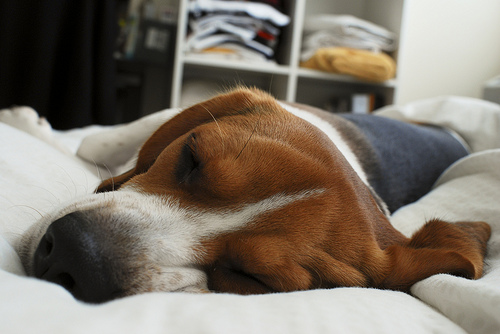

In [5]:
# read_blob() in isolation — hand it the BLOB column, get raw bytes back.
spark.sql(f"""
    SELECT image_id,
           category,
           length(read_blob(image_bytes)) AS resolved_byte_count
    FROM {TABLE_NAME}
    LIMIT 5
""").show()

# Pull one row's bytes, save as PNG, render inline — proves the bytes are real PNGs.
sample = spark.sql(f"""
    SELECT image_id, category, read_blob(image_bytes) AS img_bytes
    FROM {TABLE_NAME}
    LIMIT 1
""").collect()[0]

sample_path = Path("./outputs/read_blob_sample.png")
sample_path.parent.mkdir(parents=True, exist_ok=True)
sample_path.write_bytes(bytes(sample["img_bytes"]))
print(f"\n{sample['image_id']} ({sample['category']}) — {sample_path.stat().st_size:,} bytes")
display(IPyImage(filename=str(sample_path), width=200))

## 6. Compose: `hudi_vector_search` + `read_blob()` in one query

Now the headline. We just saw `read_blob()` on its own in §5; here it goes *inside* a `hudi_vector_search` SELECT — the TVF finds the top-K nearest neighbors via the VECTOR index, and `read_blob()` materializes the BLOB column for those K rows. **Both Hudi 1.2.0 features in one SQL, bytes loaded only for the matching rows.**

In [6]:
# Pick a random image as the query.
query_idx = np.random.randint(len(data))
query_item = data[query_idx]
print(f"Query: {query_item['image_id']} ({query_item['category']})")

array_literal = "ARRAY(" + ", ".join(f"{float(v)}" for v in query_item["embedding"]) + ")"

rows = spark.sql(f"""
    SELECT image_id,
           category,
           read_blob(image_bytes) AS resolved_bytes,
           _hudi_distance
    FROM hudi_vector_search('{TABLE_PATH}', 'embedding',
                            {array_literal}, {TOP_K + 1}, 'cosine')
    ORDER BY _hudi_distance
""").collect()

# Skip the query image itself (it's in the corpus → distance ≈ 0).
results = []
for row in rows:
    distance = float(row["_hudi_distance"])
    if distance < 0.001:
        continue
    if len(results) >= TOP_K:
        break
    results.append({
        "image_id":   row["image_id"],
        "category":   row["category"],
        "image_bytes": bytes(row["resolved_bytes"]) if row["resolved_bytes"] else b"",
        "similarity": 1.0 - distance,
    })

print(f"\n✓ Top {len(results)} matches:")
for i, r in enumerate(results, 1):
    print(f"  {i}. {r['image_id']:18s} {r['category']:30s} sim={r['similarity']:.3f}")

Query: pets_002573 (German Shorthaired)

✓ Top 5 matches:
  1. pets_002575        German Shorthaired             sim=0.622
  2. pets_000703        German Shorthaired             sim=0.516
  3. pets_002562        German Shorthaired             sim=0.402
  4. pets_002556        German Shorthaired             sim=0.393
  5. pets_003538        Staffordshire Bull Terrier     sim=0.359


## 7. Visualize

Query image on the left, top-K matches on the right.

✓ Panel saved: outputs/hudi_main_demo_results.png


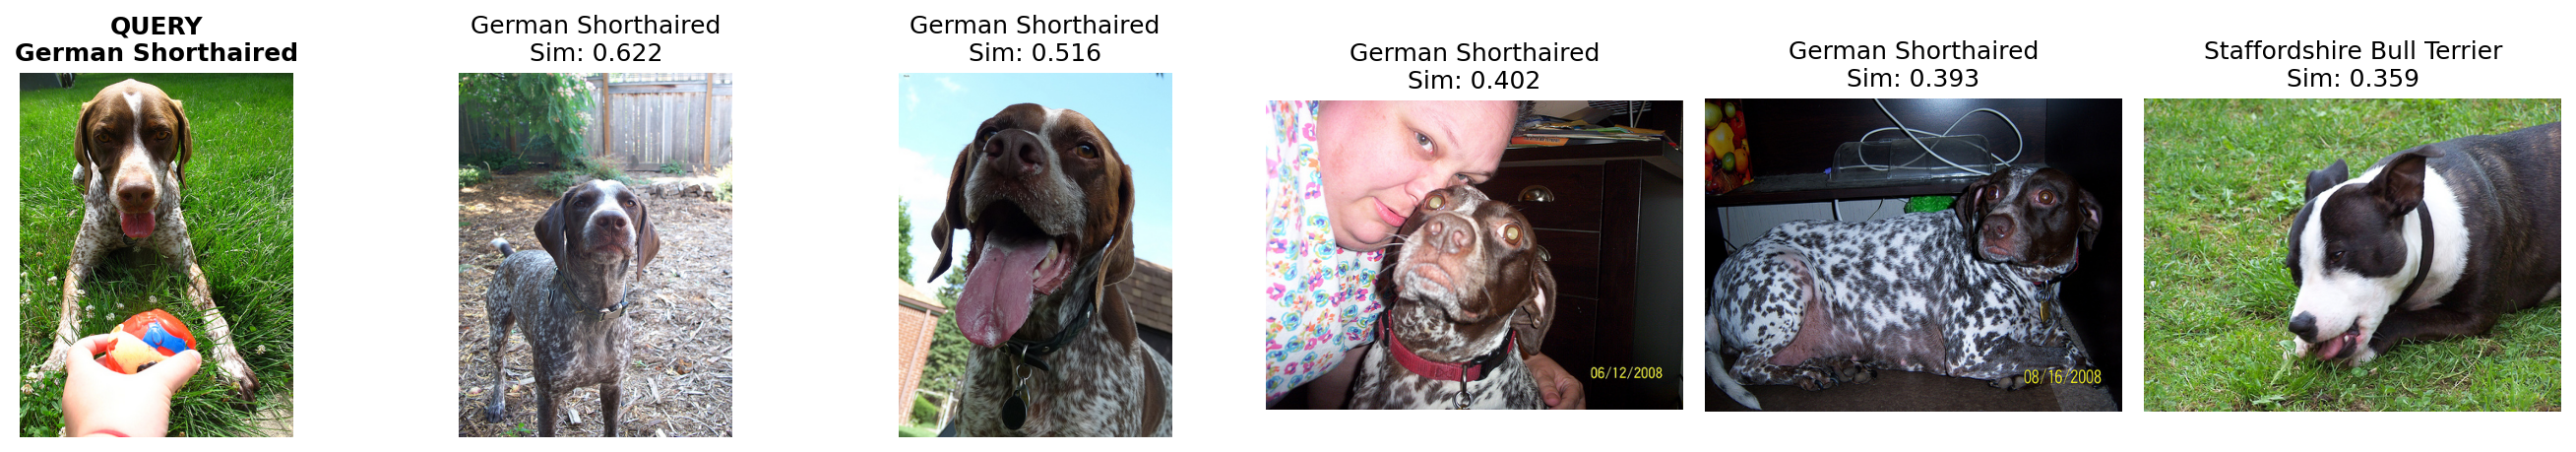

In [7]:
out_dir = Path("./outputs"); out_dir.mkdir(parents=True, exist_ok=True)

n_results = len(results)
fig, axes = plt.subplots(1, n_results + 1, figsize=(3 * (n_results + 1), 3.2))
query_img = Image.open(io.BytesIO(query_item["image_bytes_raw"])).convert("RGB")
axes[0].imshow(query_img)
axes[0].set_title(f"QUERY\n{query_item['category']}", fontweight="bold")
axes[0].axis("off")
for i, r in enumerate(results):
    img = Image.open(io.BytesIO(r["image_bytes"])).convert("RGB")
    axes[i + 1].imshow(img)
    axes[i + 1].set_title(f"{r['category']}\nSim: {r['similarity']:.3f}")
    axes[i + 1].axis("off")
plt.tight_layout()
panel_path = out_dir / "hudi_main_demo_results.png"
plt.savefig(str(panel_path), dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"✓ Panel saved: {panel_path}")
display(IPyImage(filename=str(panel_path)))